<a href="https://colab.research.google.com/github/prateeknegi332-collab/Future-intern-/blob/main/Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task_1

In [17]:
import pandas as pd


holidays_events_df = pd.read_csv('/content/holidays_events.csv')


display(holidays_events_df.head())

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [18]:
import os

files = os.listdir('/content/')
print(f"Files available in /content/: {files}")

Files available in /content/: ['.config', 'holidays_events.csv', 'sample_data']


In [19]:
import os

sample_files = os.listdir('/content/sample_data/')
print(f'Files in sample_data: {sample_files}')

Files in sample_data: ['README.md', 'anscombe.json', 'mnist_test.csv', 'california_housing_test.csv', 'mnist_train_small.csv', 'california_housing_train.csv']


In [20]:

missing_values = holidays_events_df.isnull().sum()
print('Missing values in each column:')
print(missing_values)

Missing values in each column:
date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64


In [21]:
import numpy as np


dates = pd.date_range(start='2012-01-01', end='2013-12-31', freq='D')
np.random.seed(42)
sales = 100 + 20 * np.sin(np.arange(len(dates)) * (2 * np.pi / 365)) + np.random.normal(0, 10, len(dates))

sales_df = pd.DataFrame({'date': dates.astype(str), 'sales': sales})
holidays_events_df['date'] = holidays_events_df['date'].astype(str)


df = pd.merge(sales_df, holidays_events_df, on='date', how='left')
df['is_holiday'] = df['type'].notnull().astype(int)

display(df.head())

,date,sales,type,locale,locale_name,description,transferred,is_holiday
0,2012-01-01,104.967142,NaN,NaN,NaN,NaN,NaN,0
1,2012-01-02,98.961624,NaN,NaN,NaN,NaN,NaN,0
2,2012-01-03,107.165318,NaN,NaN,NaN,NaN,NaN,0
3,2012-01-04,116.262692,NaN,NaN,NaN,NaN,NaN,0
4,2012-01-05,99.034515,NaN,NaN,NaN,NaN,NaN,0


In [22]:

df['date'] = pd.to_datetime(df['date'])


df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek
df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)


display(df[['date', 'sales', 'is_holiday', 'month', 'dayofweek', 'is_weekend']].head())

,date,sales,is_holiday,month,dayofweek,is_weekend
0,2012-01-01,104.967142,0,1,6,1
1,2012-01-02,98.961624,0,1,0,0
2,2012-01-03,107.165318,0,1,1,0
3,2012-01-04,116.262692,0,1,2,0
4,2012-01-05,99.034515,0,1,3,0


In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np


features = ['is_holiday', 'month', 'day', 'dayofweek', 'is_weekend']
X = df[features]
y = df['sales']


split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]


model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

Mean Absolute Error (MAE): 9.00
Root Mean Squared Error (RMSE): 11.26


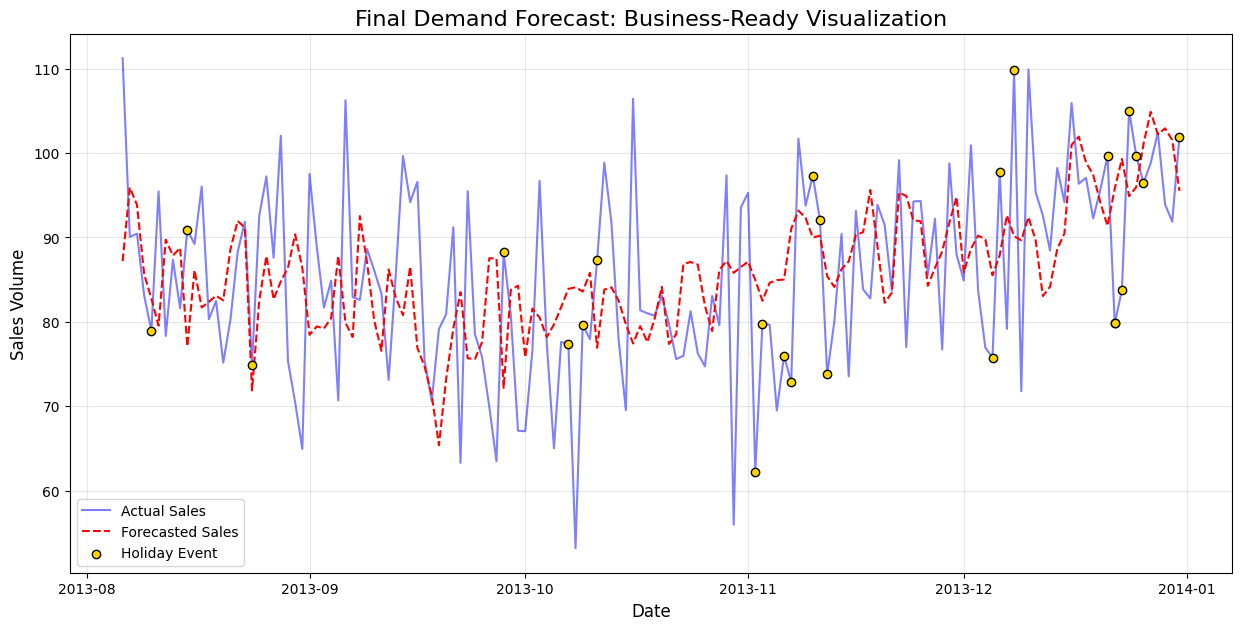

In [25]:
import seaborn as sns


results_df = df.iloc[split_index:].copy()
results_df['prediction'] = y_pred

plt.figure(figsize=(15, 7))
sns.lineplot(data=results_df, x='date', y='sales', label='Actual Sales', color='blue', alpha=0.5)
sns.lineplot(data=results_df, x='date', y='prediction', label='Forecasted Sales', color='red', linestyle='--')


holidays = results_df[results_df['is_holiday'] == 1]
plt.scatter(holidays['date'], holidays['sales'], color='gold', label='Holiday Event', zorder=5, edgecolor='black')

plt.title('Final Demand Forecast: Business-Ready Visualization', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales Volume', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Task_2

In [26]:
import zipfile
import pandas as pd


zip_path = '/content/customer_support_tickets.csv.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')


tickets_df = pd.read_csv('/content/customer_support_tickets.csv')


print(tickets_df.info())
display(tickets_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


/tmp/ipykernel_1052/4059204754.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=tickets_df, y='Ticket Type', ax=ax[0], palette='viridis', order=tickets_df['Ticket Type'].value_counts().index)
/tmp/ipykernel_1052/4059204754.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=tickets_df, x='Ticket Priority', ax=ax[1], palette='magma', order=['Low', 'Medium', 'High', 'Critical'])


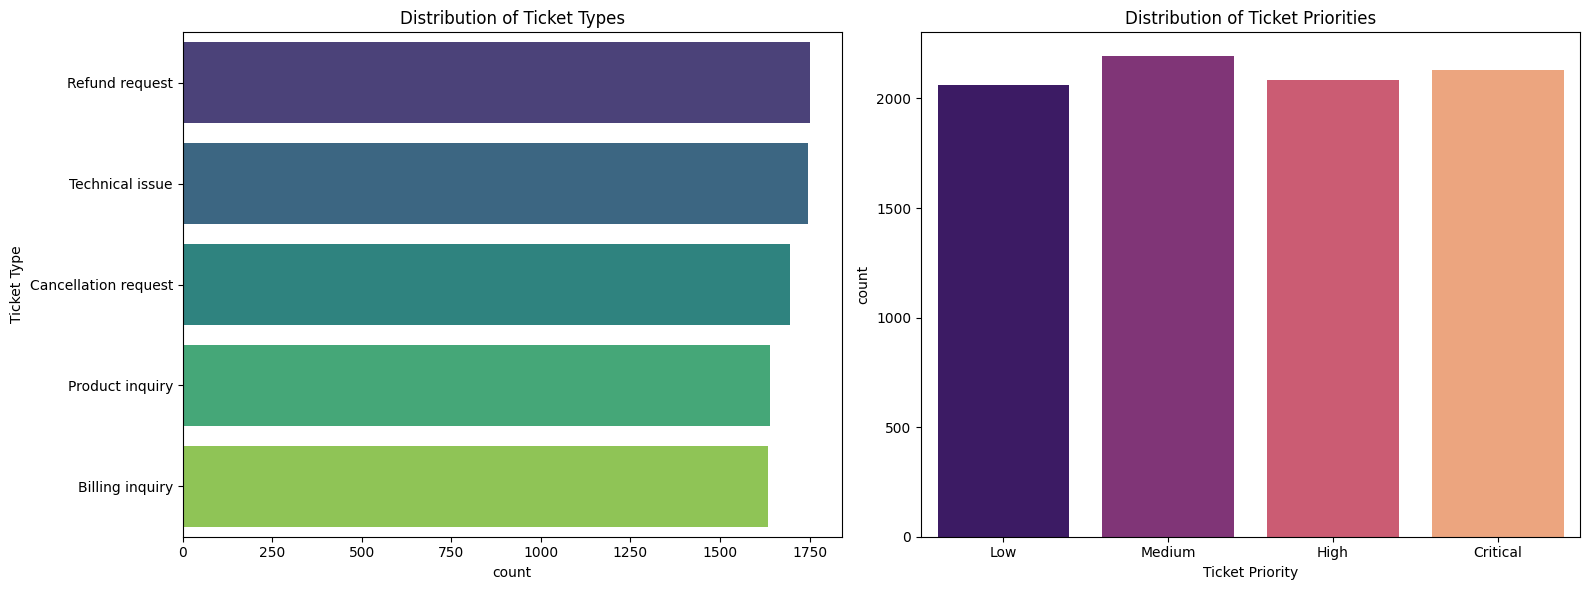

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=tickets_df, y='Ticket Type', ax=ax[0], palette='viridis', order=tickets_df['Ticket Type'].value_counts().index)
ax[0].set_title('Distribution of Ticket Types')

sns.countplot(data=tickets_df, x='Ticket Priority', ax=ax[1], palette='magma', order=['Low', 'Medium', 'High', 'Critical'])
ax[1].set_title('Distribution of Ticket Priorities')

plt.tight_layout()
plt.show()

In [30]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re


nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = re.sub(r'\{.*?\}', '', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())

    tokens = word_tokenize(text)
    cleaned_tokens = [w for w in tokens if w not in stop_words]
    return ' '.join(cleaned_tokens)


tickets_df['cleaned_description'] = tickets_df['Ticket Description'].apply(clean_text)

print("Sample of cleaned text:")
display(tickets_df[['Ticket Description', 'cleaned_description']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Sample of cleaned text:


,Ticket Description,cleaned_description
0,I'm having an issue with the {product_purchase...,im issue please assist billing zip code apprec...
1,I'm having an issue with the {product_purchase...,im issue please assist need change existing pr...
2,I'm facing a problem with my {product_purchase...,im facing problem turning working fine yesterd...
3,I'm having an issue with the {product_purchase...,im issue please assist problem youre intereste...
4,I'm having an issue with the {product_purchase...,im issue please assist note seller responsible...


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(tickets_df['cleaned_description'])


print("--- Training Ticket Type Classifier ---")
y_type = tickets_df['Ticket Type']
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_tfidf, y_type, test_size=0.2, random_state=42)

model_type = LogisticRegression(max_iter=1000)
model_type.fit(X_train_t, y_train_t)
y_pred_t = model_type.predict(X_test_t)
print(classification_report(y_test_t, y_pred_t))


print("\n--- Training Ticket Priority Classifier ---")
y_priority = tickets_df['Ticket Priority']
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_tfidf, y_priority, test_size=0.2, random_state=42)

model_priority = LogisticRegression(max_iter=1000)
model_priority.fit(X_train_p, y_train_p)
y_pred_p = model_priority.predict(X_test_p)
print(classification_report(y_test_p, y_pred_p))

--- Training Ticket Type Classifier ---
                      precision    recall  f1-score   support

     Billing inquiry       0.18      0.13      0.15       357
Cancellation request       0.19      0.20      0.20       327
     Product inquiry       0.20      0.21      0.20       316
      Refund request       0.19      0.21      0.20       345
     Technical issue       0.22      0.24      0.23       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694


--- Training Ticket Priority Classifier ---
              precision    recall  f1-score   support

    Critical       0.25      0.27      0.26       411
        High       0.25      0.26      0.26       409
         Low       0.23      0.22      0.23       415
      Medium       0.29      0.27      0.28       459

    accuracy                           0.26      1694
   macro avg       0.26     